# Modelo simple CNN

Este notebook implementa y entrena una **red neuronal convolucional (CNN)** para clasificar imágenes del juego "Piedra, Papel o Tijera", utilizando los datos previamente procesados y almacenados en formato `.npy`.

Las principales actividades realizadas son:

- Carga de los conjuntos de datos `X_hand.npy` y `y_hand.npy`
- División en datos de entrenamiento y prueba
- Normalización de las imágenes y codificación one-hot de las etiquetas
- Definición e implementación de una arquitectura CNN básica con Keras, que incluye:
  - Capa convolucional `Conv2D`
  - Capa de reducción de dimensionalidad `MaxPooling2D`
  - Capa `Flatten` y capas `Dense` para clasificación
- Entrenamiento del modelo y evaluación del desempeño
- Visualización de la precisión y la pérdida del modelo por época
- Guardado del modelo entrenado en formato `.keras`

>  Este modelo sirve como punto de partida para tareas de clasificación de imágenes con redes neuronales profundas. Se sugiere mejorar su arquitectura como ejercicio adicional.


In [39]:
!ls dataset

papel  piedra  tijera  X_hand.npy  y_hand.npy


In [40]:
from numpy import load

X = load('dataset/X_hand.npy')
y = load('dataset/y_hand.npy')

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test)

(741, 64, 64, 3)
(247, 64, 64, 3)
(741,)
[1 1 0 1 2 2 2 1 1 2 2 1 1 0 0 0 2 1 1 0 0 1 0 1 0 2 1 0 2 2 2 0 2 1 2 0 0
 2 2 1 1 0 1 2 0 1 2 2 0 0 1 1 2 1 0 2 1 2 2 1 1 2 1 2 0 1 1 1 0 0 0 2 2 0
 2 2 1 1 0 0 1 2 1 2 1 0 2 0 2 2 1 2 0 1 2 0 0 1 0 0 0 2 2 0 0 2 2 2 2 2 1
 2 2 1 0 2 1 1 1 0 0 2 1 2 0 1 2 0 0 2 2 0 1 1 2 0 0 2 0 1 2 0 0 0 2 1 2 1
 2 2 1 1 2 1 1 0 2 0 2 1 1 1 2 1 0 2 1 1 2 0 1 2 2 1 1 1 2 0 1 2 2 2 1 0 1
 1 1 1 1 0 2 1 2 2 0 1 0 1 2 0 0 0 0 2 2 1 0 1 2 1 0 1 1 0 1 1 0 0 2 0 0 0
 2 0 1 2 1 0 0 2 1 2 2 0 1 0 1 0 0 1 2 2 0 0 2 1 2]


In [42]:
X_train_scaled  = X_train / 255
X_test_scaled  = X_test / 255

In [43]:
# one hot encode outputs
from tensorflow.keras.utils import to_categorical

y_train = to_categorical( y_train )
y_test = to_categorical( y_test )

In [44]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
#from keras.layers.convolutional import Conv2D
#from keras.layers.convolutional import MaxPooling2D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D


# Primer modelo

Modelo

1. Conv 16 (3,3) , relu
2. MP (2,2)
7. Flatten
8. 128 , relu
9. num_classes, softmax

In [45]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

def modelo_CNN():
    model = Sequential()
    model.add(Input(shape=(64,64,3)))
    model.add(Conv2D(16, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3, activation='softmax'))


    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [46]:
model = modelo_CNN()
history_CNN = model.fit(   X_train_scaled, y_train, validation_data=(X_test_scaled, y_test),
                        epochs = 20 , batch_size = 10, verbose=2  )

Epoch 1/20
75/75 - 5s - 68ms/step - accuracy: 0.4858 - loss: 1.1402 - val_accuracy: 0.5385 - val_loss: 0.8746
Epoch 2/20
75/75 - 0s - 5ms/step - accuracy: 0.5843 - loss: 0.8655 - val_accuracy: 0.5709 - val_loss: 0.8042
Epoch 3/20
75/75 - 0s - 5ms/step - accuracy: 0.6532 - loss: 0.7301 - val_accuracy: 0.6761 - val_loss: 0.7096
Epoch 4/20
75/75 - 0s - 5ms/step - accuracy: 0.7503 - loss: 0.6014 - val_accuracy: 0.6599 - val_loss: 0.6311
Epoch 5/20
75/75 - 0s - 5ms/step - accuracy: 0.8421 - loss: 0.4595 - val_accuracy: 0.8097 - val_loss: 0.5205
Epoch 6/20
75/75 - 0s - 5ms/step - accuracy: 0.8880 - loss: 0.3461 - val_accuracy: 0.8543 - val_loss: 0.4524
Epoch 7/20
75/75 - 1s - 8ms/step - accuracy: 0.9420 - loss: 0.2396 - val_accuracy: 0.8381 - val_loss: 0.4497
Epoch 8/20
75/75 - 0s - 7ms/step - accuracy: 0.9298 - loss: 0.2263 - val_accuracy: 0.8381 - val_loss: 0.3948
Epoch 9/20
75/75 - 1s - 7ms/step - accuracy: 0.9622 - loss: 0.1453 - val_accuracy: 0.8502 - val_loss: 0.4046
Epoch 10/20
75/75 

In [47]:
# Final evaluation of the model
scores=model.evaluate(X_test_scaled,y_test,verbose=0)

print('Error del modelo base : %.2f%%' % (100-scores[1]*100))

Error del modelo base : 13.36%


(0.0, 2.0)

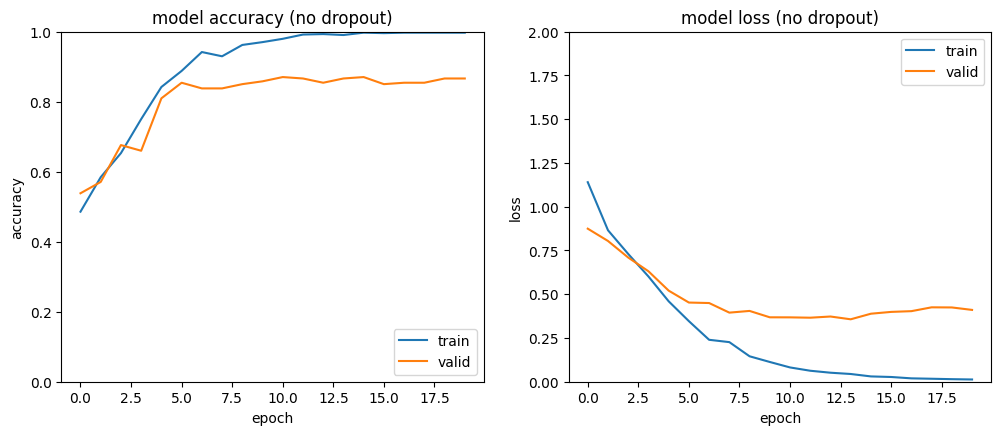

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.plot(history_CNN.history['accuracy'])
plt.plot(history_CNN.history['val_accuracy'])
plt.ylim(0, 1)
plt.title('model accuracy (no dropout)')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='lower right')
plt.subplot(2,2,2)
plt.plot(history_CNN.history['loss'])
plt.plot(history_CNN.history['val_loss'])
plt.title('model loss (no dropout)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper right')
plt.ylim([0,2])

In [37]:
model.save('modelo_CNN_NOMBRE-APELLIDO.keras')

# Segundo Modelo (TAREA)
Encontrar un nuevo modelo que sea mejor

In [38]:
model.save('modelo_CNN_NOMBRE-APELLIDO.keras')
